# V0.6
```

colabでの構成--

main.ipynb
       |___xxx.json
       |___my_plot.py
       |___【NEW】main.py  


```

* **[my_plot.py](https://github.com/kenkenkengo0421/Class_my_plt/blob/main/my_plot.py)**

In [1]:
!pip install -q kaggle-environments

# 提出関数

In [2]:
%%writefile main.py
import random

def step_toward(fx, fy, tx, ty, tiles):
    """
    最短ルートを計算
    目的地(tx, ty)に向かって安全に1歩進む

    1_X軸（東西）のチェック 目的地が右にあり、マップ右端(9)ではなく、右マスがLOCKEDでない場合：
      EASTを追加
    2_左（WEST）のチェック
    3_Y軸（南北）のチェック 目的地が下にあり、マップ下端(9)ではなく、下マスがLOCKEDでない場合：
      SOUTHを追加
    4_上（NORTH）のチェック
    5_目的地に近づく安全なルートがある場合：
      その中からランダムに1歩選ぶ（斜め移動時の角への引っかかりを防ぐため）
    6_目的地に近づけない場合：
     （障害物に塞がれている等）は、とりあえず移動可能な安全なマスを探す
    7_動ける場所があればランダム移動、完全に閉じ込められていればPASSを返す
    """
    candidates = []

    if fx < tx and fx < 9 and tiles[fy][fx + 1] != "LOCKED":
        candidates.append("EAST")
    elif fx > tx and fx > 0 and tiles[fy][fx - 1] != "LOCKED":
        candidates.append("WEST")
    if fy < ty and fy < 9 and tiles[fy + 1][fx] != "LOCKED":
        candidates.append("SOUTH")
    elif fy > ty and fy > 0 and tiles[fy - 1][fx] != "LOCKED":
        candidates.append("NORTH")
    if candidates:
        return random.choice(candidates)

    valid_dirs = []
    if fy > 0 and tiles[fy - 1][fx] != "LOCKED": valid_dirs.append("NORTH")
    if fy < 9 and tiles[fy + 1][fx] != "LOCKED": valid_dirs.append("SOUTH")
    if fx < 9 and tiles[fy][fx + 1] != "LOCKED": valid_dirs.append("EAST")
    if fx > 0 and tiles[fy][fx - 1] != "LOCKED": valid_dirs.append("WEST")

    return random.choice(valid_dirs) if valid_dirs else "PASS"

def find_target_tile(tiles, fx, fy, have_seeds, day):
    """
    一番優先度の高い仕事場(X, Y)を探す

    LOCKED_まだ買ってない未解放の土地の場合無視して次のマスへ進む
    1_植物（PLANT）が生えている場合：
      今の日数 - 植えた日数 を計算して、「この作物は植えてから何日経ったか
      作物の「種類」を確認
      作物の種類によって収穫日数を変えるメロンなら10違うなら2
      収穫できる日数なら収穫でその日に水やりしてなかったら水やり
    2_空き地（None）で、かつ種を持っている場合(plant)植える
    """
    candidates = []

    for y in range(len(tiles)):
        for x in range(len(tiles[0])):
            t = tiles[y][x]
            if t == "LOCKED": continue
            if isinstance(t, dict) and t.get("kind") == "PLANT":

                crop_age = day - t.get("planted_day", day)
                crop_name = t.get("crop", "WHEAT")
                harvest_age = 10 if crop_name == "MELON" else 2

                if crop_age >= harvest_age:
                    candidates.append((x, y, "harvest"))
                elif not t.get("watered_today", True):
                    candidates.append((x, y, "water"))

            elif t is None and have_seeds:
                candidates.append((x, y, "plant"))

    if not candidates:
        return None

    """
    仕事の優先順位を定義（数字が小さいほど最優先。収穫 > 水やり > 種まき
    候補リストを並び替える
    基準1: 上記の優先順位（最重要）
    基準2: 現在地(fx, fy)からのマンハッタン距離（近いものを優先）
    一番条件の良い仕事場の座標(X, Y)を返す

    """

    priority = {"harvest": 0, "water": 1, "plant": 2}
    candidates.sort(key=lambda c: (priority[c[2]], abs(c[0] - fx) + abs(c[1] - fy)))
    return candidates[0][0], candidates[0][1]




def agent(obs, config):
    player = obs["player"]
    me = obs["farms"][player]
    private = obs["private"]

    fx, fy = me["farmer"]
    tiles = me["tiles"]
    tile = tiles[fy][fx]

    # 辞書にキーが無い場合のエラーを防ぐ
    money = me.get("money", 0)
    seeds = private.get("seeds", {})
    shed = private.get("shed", {})
    day = obs.get("day", 0)
    step = obs.get("step", 0)

    # 現在の労働者のリストを取得
    current_hands = me.get("hands", [])
    market = []

    # ========================================
    # 1. 市場での売買・雇用ロジック
    # ========================================

    """
    1_資金が500ドル以上ならメロン農家にシフト
    2_小麦は資金繰りのためすぐに売る
    3_終盤の店じまい
    4_労働者が0人で、お金が十分にある時だけ1人雇う
    """

    wheat_seeds = seeds.get("WHEAT", 0)
    melon_seeds = seeds.get("MELON", 0)
    wheat_in_shed = shed.get("WHEAT", 0)
    melon_in_shed = shed.get("MELON", 0)

    #1
    if money >= 500:
        if melon_seeds == 0:
            market.append(["BUY_SEED", "MELON", 1])
    else:
        if wheat_seeds == 0 and money >= 10:
            market.append(["BUY_SEED", "WHEAT", 1])
    #2
    if wheat_in_shed > 0:
        market.append(["SELL", "WHEAT", wheat_in_shed])
    #3
    if step >= 710:
        if melon_in_shed > 0:
            market.append(["SELL", "MELON", melon_in_shed])
    elif melon_in_shed >= 5:
        market.append(["SELL", "MELON", melon_in_shed])
    #4
    if money >= 100 and len(current_hands) == 0:
        market.append(["HIRE"])

    # ========================================
    # 2. メイン農家のアクション
    # ========================================

    """
    1_足元が空き地の場合
    2_種を持ってたら植える
    3_足元に植物がある場合
    4_今の日数 - 植えた日数 を計算して、「この作物は植えてから何日経ったか
      作物の「種類」を確認
    5_足元の作物がメロンなら10日待つ小麦なら2日待つ
    6_作物が育った日数（crop_age）が、収穫に必要な日数（harvest_age）に達している場合
    7_今日の水やりがまだなら水やり
    """


    farmer_action = None

    #1
    if tile is None:

    #2
        if melon_seeds > 0:
            farmer_action = ["PLANT", "MELON"]
        elif wheat_seeds > 0:
            farmer_action = ["PLANT", "WHEAT"]
    #3
    elif isinstance(tile, dict) and tile.get("kind") == "PLANT":

    #4
        crop_age = day - tile.get("planted_day", day)
        crop_name = tile.get("crop", "WHEAT")
    #5
        harvest_age = 10 if crop_name == "MELON" else 2

    #6
        if crop_age >= harvest_age:
            farmer_action = ["HARVEST"]
    #7
        elif not tile.get("watered_today", True):
            farmer_action = ["WATER"]

    # ========================================
    # 3. 農家の移動
    # ========================================

    """
    1_足元でやることがなかった場合、レーダーを使って次の目的地を探す
    2_目的地が見つかれば、ナビを使って1歩進む
    3_畑全体に仕事がなければ待機
    """

    #1
    if farmer_action is None:
        has_any_seed = (wheat_seeds > 0) or (melon_seeds > 0)
        target = find_target_tile(tiles, fx, fy, has_any_seed, day)

        if target:
    #2
            move_dir = step_toward(fx, fy, target[0], target[1], tiles)
            farmer_action = [move_dir]
        else:
    #3
            farmer_action = ["PASS"]

    # ========================================
    # 4. 労働者(hands)の行動
    # ========================================

    """
    1_雇っている人数分だけループを回して、個別に指示を出す
    2_足元の作物がメロンなら10日待つ小麦なら2日待つ
    3_農家と同じように一番近い仕事場へ向かって進む
    """

    hands_actions = []

    #1
    for hand in current_hands:
        hx, hy = hand
        hand_tile = tiles[hy][hx]
        hand_action = None

        if isinstance(hand_tile, dict) and hand_tile.get("kind") == "PLANT":

            crop_age = day - hand_tile.get("planted_day", day)
            crop_name = hand_tile.get("crop", "WHEAT")

    #2
            harvest_age = 10 if crop_name == "MELON" else 2

            if crop_age >= harvest_age:
                hand_action = ["HARVEST"]
            elif not hand_tile.get("watered_today", True):
                hand_action = ["WATER"]

    #3
        if hand_action is None:
            target = find_target_tile(tiles, hx, hy, False, day)
            if target:
                move_dir = step_toward(hx, hy, target[0], target[1], tiles)
                hand_action = [move_dir]
            else:
                hand_action = ["PASS"]

        hands_actions.append(hand_action)

    return {
        "farmer": farmer_action,
        "hands": hands_actions,
        "market": market
    }

Overwriting main.py


# デバッグ、テスト

In [3]:
from zoneinfo import ZoneInfo
import datetime
from kaggle_environments import make
from IPython.display import HTML



print(datetime.datetime.now(ZoneInfo("Asia/Tokyo")))


env = make("kaggriculture", configuration={"episodeSteps": 720}, debug=True)

env.run(["main.py", "random"])

final = env.steps[-1]
for i, s in enumerate(final):
    print(f"Player {i}: reward={s.reward}, status={s.status}")
"""
html_output = env.render(mode="html", width=500, height=500)
HTML(html_output)
"""

2026-08-06 02:02:11.011834+09:00
Player 0: reward=29853.0, status=DONE
Player 1: reward=0.0, status=DONE


'\nhtml_output = env.render(mode="html", width=500, height=500)\nHTML(html_output)\n'

# 分析用



| 階層1 (トップレベル) | 階層2 (`steps`内) | 階層3 (詳細) | 記録されている内容 |
| :--- | :--- | :--- | :--- |
| `configuration` | | | ゲームの設定値（最大ターン数720、初期資金3000、ボードサイズなど） |
| `info` | | | 対戦プレイヤーの名前やシード値 |
| `rewards` | | | 最終的なスコア（所持金） |
| `steps` | | | ターンごとの全記録が入ったリスト（分析において最も重要） |
| | `action` | | そのターンにプレイヤーが送ったコマンド |
| | | `farmer` | メイン農家の行動（例: `["PLANT", "WHEAT"]` など） |
| | | `hands` | 労働者たちの行動リスト |
| | | `market` | 市場での売買・雇用アクション（例: `["BUY_SEED", "WHEAT", 1]`, `["HIRE"]` など） |
| | `observation` | | そのターンのゲーム内の全状況 |
| | | `step` / `day` / `hour` | 現在の進行度（何日目の何時間目か） |
| | | `market` | 市場の状況（`prices`: 現在の価格、`inventory`: 市場の在庫数） |
| | | `farms` | プレイヤー0と1（敵）の農場状態（`money`: 所持金、`tiles`: 10x10のマス目の状態、`farmer` / `hands`: 座標、`hires_today`: 今日の雇用人数） |
| | | `private` | 自分だけが見える非公開情報（`shed`: 小屋の収穫物在庫、`seeds`: 所持している種の数） |
| | | `town` | 町の状況（`unlocked_shops`: 解放されているショップのリスト） |
| | `reward` | | その時点でのスコア（所持金と同値） |
| | `status` | | エラー落ちしていないか（"ACTIVE" または "DONE"） |

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
import numpy as np
from my_plot import sns_line_s



def j_log(file):
    with open(file, 'r') as f:
        log = json.load(f)

    print(f"""
========================================================
json file {file} を読み込み完了...
========================================================
""")
    data_list = []
    for i, step in enumerate(log['steps']):
        if i == 0: continue

        # プレイヤー0（勝者と仮定）のデータと市場データを取得
        obs = step[0]['observation']
        market_prices = obs['market']['prices']
        p0_money = obs['farms'][0]['money']

        # プレイヤー0のマーケットアクション（売買履歴）
        p0_market_action = step[0]['action'].get('market', [])

        # 小屋の在庫（ホールドしている数）
        p0_shed = obs['private']['shed']

        # データを1行にまとめる
        row = {

            'step': i,
            'p0_money': p0_money,
            'wheat_price': market_prices.get('WHEAT', 0),
            'melon_price': market_prices.get('MELON', 0),
            'wheat_in_shed': p0_shed.get('WHEAT', 0),
            'melon_in_shed': p0_shed.get('MELON', 0),
            'market_action': str(p0_market_action) if p0_market_action else ""
        }

        data_list.append(row)

    # ※ループの中で変換すると重いため、この1行だけループの外に出しています
    df = pd.DataFrame(data_list)

    print(f"""
========================================================
分析用json file【{file}】column一覧です
========================================================


{df.columns.tolist()}

{df.columns.tolist()[0]}:ステップ数
{df.columns.tolist()[1]}:プレイヤー0の所持金
{df.columns.tolist()[2]}:'WHEAT'の値段
{df.columns.tolist()[3]}:'MELON'の値段
{df.columns.tolist()[4]}:'WHEAT'の小屋の在庫
{df.columns.tolist()[5]}:'MELON'小屋の在庫
{df.columns.tolist()[6]}: 市場での売買・雇用アクション

""")

    print("""
========================================================
グラフを描画しています...
========================================================
""")

    cols_to_plot = [
        'p0_money',
        'wheat_price',
        'melon_price',
        'wheat_in_shed',
        'melon_in_shed'
    ]


    sns_line_s(df, x='step', y=cols_to_plot, step=30)

    print(df["market_action"].value_counts())

    final_money = df['p0_money'].iloc[-1]

    print(f"""
========================================================
最後に残ったお金: {final_money} ＄
========================================================
    """)

    return df


json file 90203848.json を読み込み完了...


分析用json file【90203848.json】column一覧です


['step', 'p0_money', 'wheat_price', 'melon_price', 'wheat_in_shed', 'melon_in_shed', 'market_action']

step:ステップ数
p0_money:プレイヤー0の所持金
wheat_price:'WHEAT'の値段
melon_price:'MELON'の値段
wheat_in_shed:'WHEAT'の小屋の在庫
melon_in_shed:'MELON'小屋の在庫
market_action: 市場での売買・雇用アクション



グラフを描画しています...



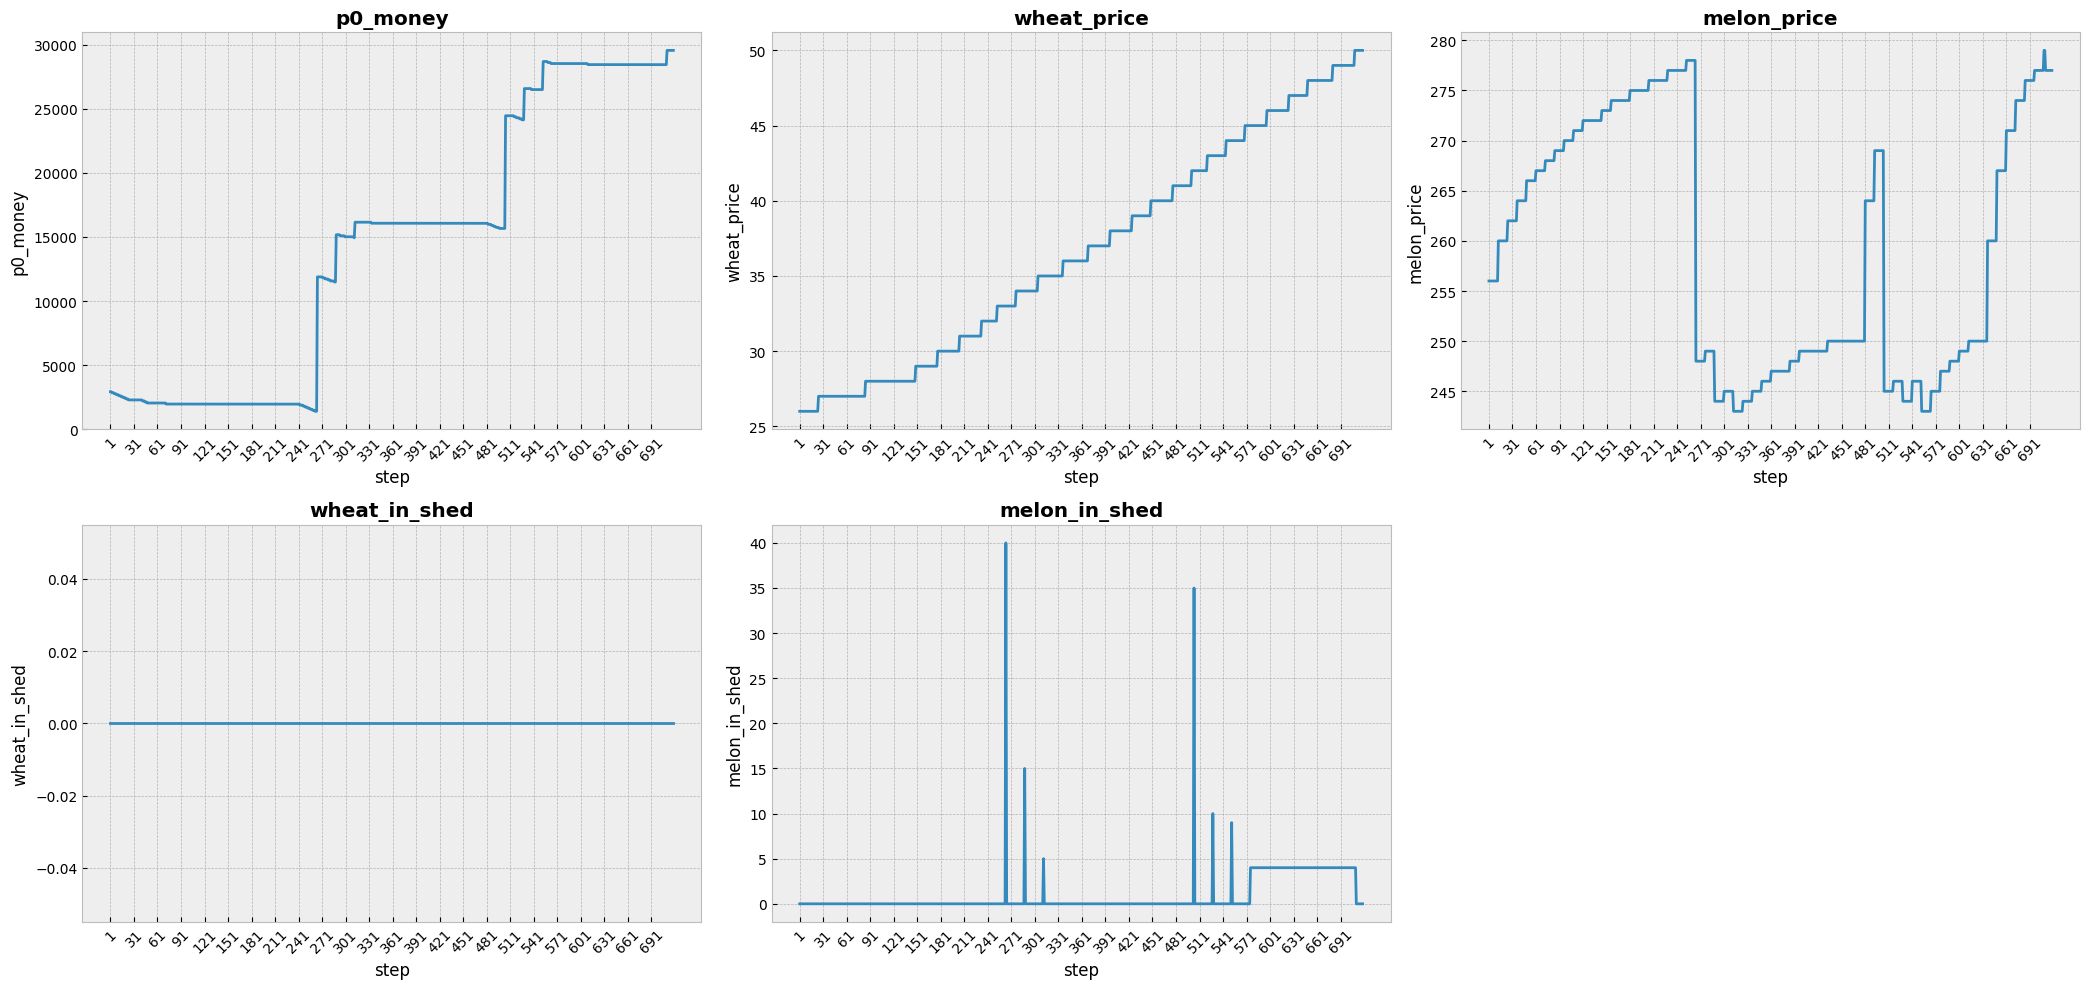

market_action
                                        647
[['BUY_SEED', 'MELON', 1]]               41
[['HIRE']]                               23
[['BUY_SEED', 'MELON', 1], ['HIRE']]      1
[['SELL', 'MELON', 40], ['HIRE']]         1
[['SELL', 'MELON', 15], ['HIRE']]         1
[['SELL', 'MELON', 5], ['HIRE']]          1
[['SELL', 'MELON', 35], ['HIRE']]         1
[['SELL', 'MELON', 10], ['HIRE']]         1
[['SELL', 'MELON', 9], ['HIRE']]          1
[['SELL', 'MELON', 4]]                    1
Name: count, dtype: int64

最後に残ったお金: 29571.0 ＄
    


In [5]:
df = j_log('90203848.json')